# ***Importing libraries and The data***

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

import glob
import os


In [267]:
device = "cuda" if torch.cuda.is_available() else "cpu" 
print("Device available: ", device)

Device available:  cuda


In [268]:
First_degree = os.path.join("..", "data", "1st degree")
Second_degree = os.path.join("..", "data", "2nd degree")
Third_degree = os.path.join("..", "data", "3rd degree")

In [269]:
first_degree_images = glob.glob(os.path.join(First_degree, "*"))
second_degree_images = glob.glob(os.path.join(Second_degree, "*"))
third_degree_images = glob.glob(os.path.join(Third_degree, "*"))
print(f"Number of first degree burn images: {len(first_degree_images)}")
print(f"Number of second degree burn images: {len(second_degree_images)}")
print(f"Number of third degree burn images: {len(third_degree_images)}")

Number of first degree burn images: 543
Number of second degree burn images: 488
Number of third degree burn images: 326


In [270]:
all_images = first_degree_images + second_degree_images + third_degree_images
labels = [0] * len(first_degree_images) + [1] * len(second_degree_images) + [2] * len(third_degree_images)
data = pd.DataFrame({"image_path": all_images, "label": labels})

print(f"Total number of images: {len(data)}")
print(data.head())

Total number of images: 1357
                                          image_path  label
0  ..\data\1st degree\gettyimages-114329113-612x6...      0
1  ..\data\1st degree\gettyimages-1263088074-612x...      0
2  ..\data\1st degree\gettyimages-1411774798-612x...      0
3  ..\data\1st degree\gettyimages-1413010078-612x...      0
4  ..\data\1st degree\gettyimages-155427805-612x6...      0


# ***Data Splitting***

In [271]:
# Split the data into training, validation and testing sets

train_data, temp_data = train_test_split(data, test_size=0.3, stratify=data["label"], random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, stratify=temp_data["label"], random_state=42)

# ***Augmentation***

In [272]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [273]:
class BurnDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["image_path"]
        label = self.dataframe.iloc[idx]["label"]
        
        from PIL import Image
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [274]:
# Create datasets
train_dataset = BurnDataset(train_data, transform=train_transforms)
val_dataset = BurnDataset(val_data, transform=val_transforms)
test_dataset = BurnDataset(test_data, transform=val_transforms)

In [275]:
# Create data loaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [276]:
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 60
Val batches: 13
Test batches: 13


In [277]:
dataset = ImageFolder(root=os.path.join("..", "data"), transform=val_transforms)
def show_img(img, label):
    print("Label:", dataset.classes[label], "(Class No: "+ str(label) + ")")
    plt.imshow(img.permute(1, 2, 0))

Label: 1st degree (Class No: 0)


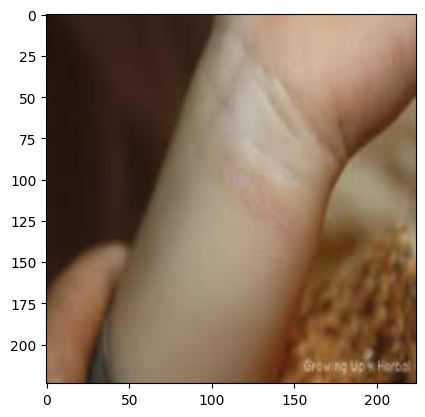

In [278]:
from PIL import Image
row = val_dataset.dataframe.iloc[1]
img = Image.open(row.image_path).convert("RGB")
img_tensor = val_transforms(img)
show_img(img_tensor, row.label)

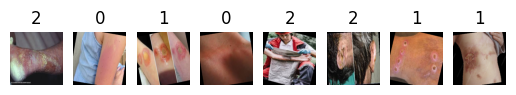

In [279]:
import matplotlib.pyplot as plt

def show_batch(dl, n=8):
    imgs, labs = next(iter(dl))
    for i in range(n):
        img = imgs[i].permute(1,2,0).cpu().numpy()
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title(labs[i].item())
        plt.axis('off')

show_batch(train_loader)

# ***Model***

In [280]:
# Define the training loop and evaluation functions
class BurnClassification():

    # Initialize the model, loss function, and optimizer
    def training_step(self, batch_size):
        image, labels = batch_size
        # Move tensors to the same device as the model
        device = next(self.parameters()).device
        image = image.to(device)
        labels = labels.to(device)
        output = self(image) 
        loss = F.cross_entropy(output, labels)
        _, preds = torch.max(output, dim=1)
        acc = torch.sum(preds == labels.data) / len(labels)
        return loss, acc
    
    # Define the validation step and epoch end functions
    def validation_step(self, batch_size):
        image, labels = batch_size
        # Move tensors to the same device as the model
        device = next(self.parameters()).device
        image = image.to(device)
        labels = labels.to(device)
        output = self(image) 
        loss = F.cross_entropy(output, labels)
        _, preds = torch.max(output, dim=1)
        acc = torch.sum(preds == labels.data) / len(labels)
        return {'val_loss': loss, 'val_acc': acc}
    
    # Define the epoch end function to compute average loss and accuracy for the epoch
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean() 
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean() 
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    # Define the epoch end function to print the results at the end of each epoch
    def epoch_end(self, epoch, result):
        print(f"Epoch: {epoch+1} Train Loss: {result['train_loss']:.4f}, Train Accuracy: {result['train_acc']:.4f},\n" \
            f"          Validation Loss: {result['val_loss']:.4f}, Validation Accuracy: {result['val_acc']:.4f}")
        print("="*75)


# ***Testing with Baseline Model***

In [ ]:
# Load the model with default pre-trained weights
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in resnet50.parameters():
    param.requires_grad = False

num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, 3)



In [282]:
resnet50_model = resnet50.to(device)
summary(resnet50_model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [283]:
# Create a model class that inherits from BurnClassification and nn.Module
class ResNet50BurnClassifier(BurnClassification, nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, x):
        return self.model(x)

# ***Training The Model***

In [284]:
@torch.no_grad()

# Define the evaluation function to compute validation loss and accuracy
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

# Define the training loop to train the model for a given number of epochs and learning rate
def fit(epochs, lr, model, train_loader, val_loader, opt_func=Adam):
    numbers = []
    optimizer = opt_func(model.parameters(), lr)

    # Train the model for the specified number of epochs
    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_accs = []
        for batch in train_loader:
            loss, acc = model.training_step(batch)
            train_losses.append(loss)
            train_accs.append(acc)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Evaluate the model on the validation set at the end of each epoch
        result = evaluate(model, val_loader)
        result["train_loss"] = torch.stack(train_losses).mean().item()
        result["train_acc"] = torch.stack(train_accs).mean().item()
        model.epoch_end(epoch, result)
        numbers.append(result)
    return numbers


In [285]:
model = ResNet50BurnClassifier(resnet50_model)

In [288]:
num_epochs = 50
optim_function = Adam
lr = 1e-7

In [289]:
history = fit(num_epochs, lr, model, train_loader, val_loader, optim_function)

Epoch: 1 Train Loss: 1.1594, Train Accuracy: 0.3492,
          Validation Loss: 1.1344, Validation Accuracy: 0.3958
Epoch: 2 Train Loss: 1.1723, Train Accuracy: 0.3408,
          Validation Loss: 1.1292, Validation Accuracy: 0.4054


KeyboardInterrupt: 